# Program 5 — Vehicle Detection System

**Aim:** Implement and evaluate a Vehicle Detection System using OpenCV to detect
vehicles in a road image and draw bounding boxes around the detected vehicles.

**Method:** A pretrained SSD MobileNet v3 (COCO) model is loaded with the OpenCV
DNN module. Only the vehicle classes are kept.

> Run `uv run download_model.py` once before this notebook to fetch the model files.

In [1]:
import os
import cv2
import numpy as np

import matplotlib.pyplot as plt


def show(img, title):
    """Display a BGR or grayscale OpenCV image inside the notebook."""
    plt.figure(figsize=(12, 7))
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


In [2]:
CONFIG = "ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt"
WEIGHTS = "frozen_inference_graph.pb"

for f in (CONFIG, WEIGHTS):
    if not os.path.exists(f):
        raise FileNotFoundError(f"{f} not found - run: uv run download_model.py")

print("Model files found.")

Model files found.


In [3]:
classNames = [
    "background", "person", "bicycle", "car", "motorcycle", "airplane", "bus",
    "train", "truck", "boat", "traffic light", "fire hydrant", "street sign",
    "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "hat", "backpack",
    "umbrella", "shoe", "eye glasses", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "plate", "wine glass",
    "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich",
    "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake",
    "chair", "couch", "potted plant", "bed", "mirror", "dining table", "window",
    "desk", "toilet", "door", "tv", "laptop", "mouse", "remote", "keyboard",
    "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator",
    "blender", "book", "clock", "vase", "scissors", "teddy bear", "hair drier",
    "toothbrush"
]

net = cv2.dnn_DetectionModel(WEIGHTS, CONFIG)
net.setInputSize(320, 320)
net.setInputScale(1.0 / 127.5)
net.setInputMean((127.5, 127.5, 127.5))
net.setInputSwapRB(True)

print("Network loaded,", len(classNames), "classes")

Network loaded, 91 classes


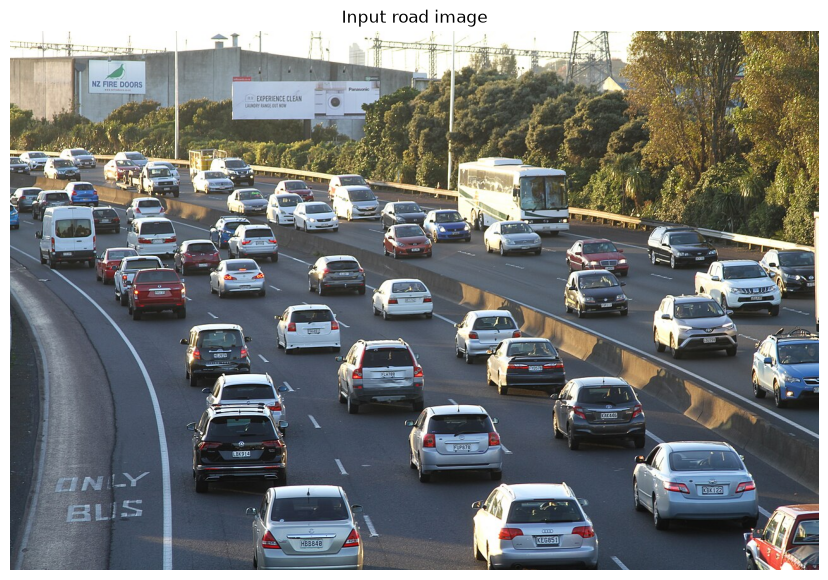

In [4]:
image = cv2.imread("vehicle.jpg")
if image is None:
    raise FileNotFoundError("vehicle.jpg not found")

output = image.copy()
show(image, "Input road image")

In [5]:
classIds, scores, boxes = net.detect(image, confThreshold=0.45, nmsThreshold=0.40)

classIds = np.array(classIds).flatten()
scores = np.array(scores).flatten()

print("Raw detections:", len(classIds))

Raw detections: 12


In [6]:
vehicle_names = {"car", "motorcycle", "bus", "truck", "bicycle"}
count = 0

for classId, score, box in zip(classIds, scores, boxes):

    classId = int(classId)
    if classId >= len(classNames):
        continue

    name = classNames[classId]
    if name not in vehicle_names:
        continue

    x, y, w, h = box

    # Ignore boxes covering most of the frame - they are false positives
    if w * h > 0.4 * image.shape[0] * image.shape[1]:
        continue

    count += 1
    cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(output, f"{name} {score:.2f}", (x, max(y - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

print("Vehicles detected:", count)

Vehicles detected: 11


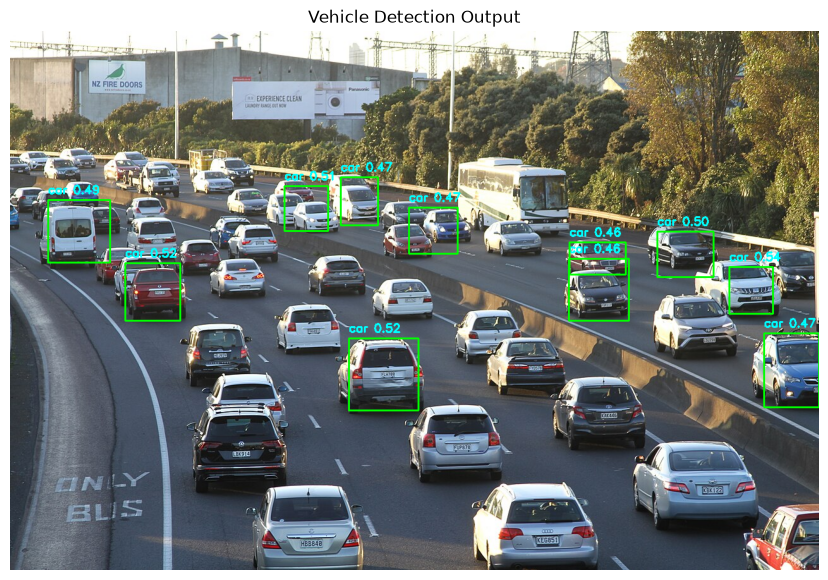

In [7]:
cv2.imwrite("output.jpg", output)
show(output, "Vehicle Detection Output")